In [1]:
# ============================================================
# Conditional Value-at-Risk (CVaR) Portfolio Optimization
# Historical Simulation Method
# Benchmark : NIFTY 50
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.optimize import minimize

# ============================================================
# NIFTY STOCKS
# ============================================================

assets = [

    "RELIANCE.NS",
    "TCS.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "INFY.NS",
    "ITC.NS",
    "LT.NS",
    "SBIN.NS",
    "BHARTIARTL.NS",
    "HINDUNILVR.NS"

]

benchmark = "^NSEI"

# ============================================================
# DOWNLOAD DATA
# ============================================================

prices = yf.download(

    assets,

    start="2020-01-01",

    end="2025-01-01",

    auto_adjust=True,

    progress=False

)["Close"]

benchmark_prices = yf.download(

    benchmark,

    start="2020-01-01",

    end="2025-01-01",

    auto_adjust=True,

    progress=False

)["Close"].squeeze()

# ============================================================
# DAILY RETURNS
# ============================================================

returns = prices.pct_change().dropna()

benchmark_returns = benchmark_prices.pct_change().dropna()

# ============================================================
# ANNUALIZED STATISTICS
# ============================================================

mean_returns = returns.mean() * 252

cov_matrix = returns.cov() * 252

num_assets = len(assets)

risk_free_rate = 0.06

confidence_level = 0.95

# ============================================================
# PORTFOLIO RETURN
# ============================================================

def portfolio_return(weights):

    return np.dot(
        weights,
        mean_returns
    )

# ============================================================
# PORTFOLIO DAILY RETURNS
# ============================================================

def portfolio_daily_returns(weights):

    return returns.dot(weights)

# ============================================================
# HISTORICAL VAR
# ============================================================

def portfolio_var(weights):

    portfolio = portfolio_daily_returns(weights)

    return np.percentile(

        portfolio,

        (1-confidence_level)*100

    )

# ============================================================
# HISTORICAL CVAR
# ============================================================

def portfolio_cvar(weights):

    portfolio = portfolio_daily_returns(weights)

    var = portfolio_var(weights)

    return portfolio[
        portfolio <= var
    ].mean()

# ============================================================
# INITIAL PORTFOLIO
# ============================================================

initial_weights = np.ones(num_assets) / num_assets

print("="*70)
print("CVAR PORTFOLIO OPTIMIZATION")
print("="*70)

print("\nAssets :", num_assets)

print("Confidence Level :", confidence_level)

print("Risk-Free Rate :", risk_free_rate)

print("\nInitial Portfolio")

print("Annual Return :",
      round(
          portfolio_return(
              initial_weights
          ),
          4
      )
)

print("Historical VaR :",
      round(
          portfolio_var(
              initial_weights
          ),
          4
      )
)

print("Historical CVaR :",
      round(
          portfolio_cvar(
              initial_weights
          ),
          4
      )
)

CVAR PORTFOLIO OPTIMIZATION

Assets : 10
Confidence Level : 0.95
Risk-Free Rate : 0.06

Initial Portfolio
Annual Return : 0.2062
Historical VaR : -0.0148
Historical CVaR : -0.0274


In [2]:
# ============================================================
# OBJECTIVE FUNCTION
# ============================================================

def objective(weights):

    return abs(
        portfolio_cvar(weights)
    )

# ============================================================
# TARGET RETURN
# ============================================================

target_return = mean_returns.mean()

# ============================================================
# CONSTRAINTS
# ============================================================

constraints = (

    {
        "type":"eq",
        "fun":lambda w: np.sum(w)-1
    },

    {
        "type":"ineq",
        "fun":lambda w:
            portfolio_return(w)
            - target_return
    }

)

# ============================================================
# BOUNDS
# ============================================================

bounds = tuple(

    (0.05,0.30)

    for _ in range(num_assets)

)

# ============================================================
# OPTIMIZATION
# ============================================================

result = minimize(

    objective,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)

optimal_weights = result.x

# ============================================================
# OPTIMAL PORTFOLIO
# ============================================================

weights_df = pd.DataFrame({

    "Asset":assets,

    "Weight":np.round(
        optimal_weights,
        4
    )

})

portfolio_return_opt = portfolio_return(
    optimal_weights
)

portfolio_var_opt = portfolio_var(
    optimal_weights
)

portfolio_cvar_opt = portfolio_cvar(
    optimal_weights
)

print("="*70)
print("CVAR OPTIMIZED PORTFOLIO")
print("="*70)

print("\nPortfolio Weights")

print(weights_df)

print("\nPortfolio Statistics")

print("-"*70)

print(f"Annual Return : {portfolio_return_opt:.4f}")

print(f"Historical VaR : {portfolio_var_opt:.4f}")

print(f"Historical CVaR : {portfolio_cvar_opt:.4f}")

print("\nOptimization Success :", result.success)

print("Message :", result.message)

CVAR OPTIMIZED PORTFOLIO

Portfolio Weights
           Asset  Weight
0    RELIANCE.NS  0.2153
1         TCS.NS  0.0500
2    HDFCBANK.NS  0.2086
3   ICICIBANK.NS  0.0500
4        INFY.NS  0.0895
5         ITC.NS  0.1680
6          LT.NS  0.0500
7        SBIN.NS  0.0500
8  BHARTIARTL.NS  0.0500
9  HINDUNILVR.NS  0.0686

Portfolio Statistics
----------------------------------------------------------------------
Annual Return : 0.2062
Historical VaR : -0.0137
Historical CVaR : -0.0244

Optimization Success : True
Message : Optimization terminated successfully


In [3]:
# ============================================================
# MEAN-VARIANCE PORTFOLIO
# ============================================================

def mv_objective(weights):

    return np.dot(
        weights.T,
        np.dot(cov_matrix, weights)
    )

mv_result = minimize(

    mv_objective,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)

mv_weights = mv_result.x

# ============================================================
# DAILY RETURNS
# ============================================================

cvar_returns = returns.dot(optimal_weights)

mv_returns = returns.dot(mv_weights)

benchmark_series = benchmark_returns.squeeze()

# ============================================================
# PERFORMANCE FUNCTION
# ============================================================

def performance_metrics(return_series):

    annual_return = return_series.mean() * 252

    annual_volatility = (
        return_series.std() * np.sqrt(252)
    )

    sharpe = (
        annual_return - risk_free_rate
    ) / annual_volatility

    years = len(return_series) / 252

    cumulative = (1 + return_series).cumprod()

    cagr = (
        cumulative.iloc[-1] ** (1 / years)
    ) - 1

    running_max = cumulative.cummax()

    drawdown = (
        cumulative - running_max
    ) / running_max

    max_drawdown = drawdown.min()

    var95 = np.percentile(
        return_series,
        5
    )

    cvar95 = return_series[
        return_series <= var95
    ].mean()

    return [

        annual_return,

        annual_volatility,

        sharpe,

        cagr,

        max_drawdown,

        var95,

        cvar95

    ]

# ============================================================
# METRICS
# ============================================================

cvar_metrics = performance_metrics(
    cvar_returns
)

mv_metrics = performance_metrics(
    mv_returns
)

benchmark_metrics = performance_metrics(
    benchmark_series
)

# ============================================================
# COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Metric":[

        "Annual Return",

        "Annual Volatility",

        "Sharpe Ratio",

        "CAGR",

        "Maximum Drawdown",

        "VaR (95%)",

        "CVaR (95%)"

    ],

    "CVaR Portfolio":cvar_metrics,

    "Mean-Variance":mv_metrics,

    "NIFTY 50":benchmark_metrics

})

print("="*80)
print("CVAR PORTFOLIO vs MEAN-VARIANCE vs NIFTY 50")
print("="*80)

print(comparison.round(4))

CVAR PORTFOLIO vs MEAN-VARIANCE vs NIFTY 50
              Metric  CVaR Portfolio  Mean-Variance  NIFTY 50
0      Annual Return          0.2062         0.2062    0.1537
1  Annual Volatility          0.1750         0.1736    0.1912
2       Sharpe Ratio          0.8354         0.8420    0.4903
3               CAGR          0.2101         0.2104    0.1448
4   Maximum Drawdown         -0.2927        -0.2949   -0.3844
5          VaR (95%)         -0.0137        -0.0144   -0.0163
6         CVaR (95%)         -0.0244        -0.0247   -0.0295


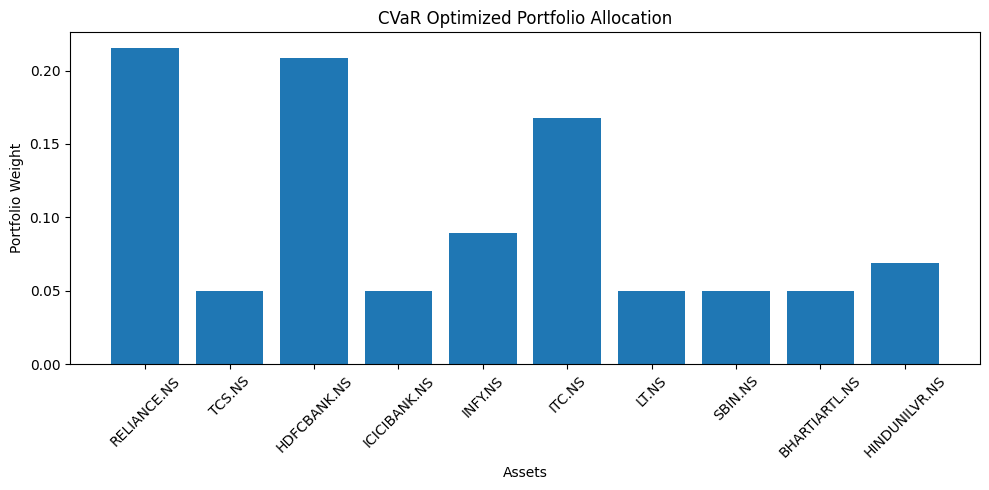

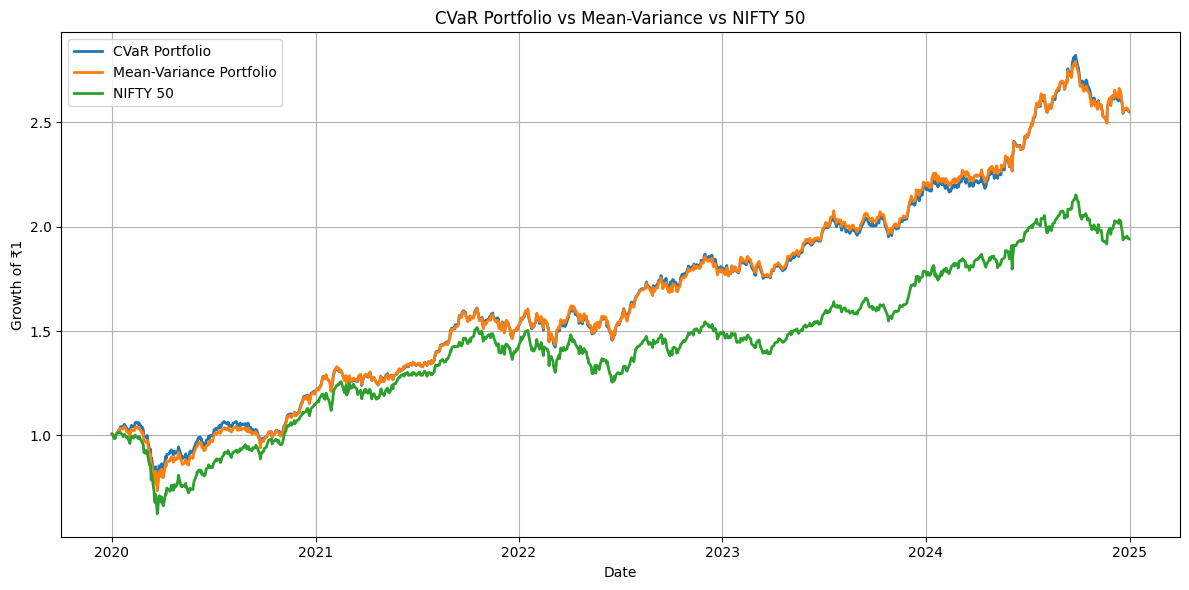

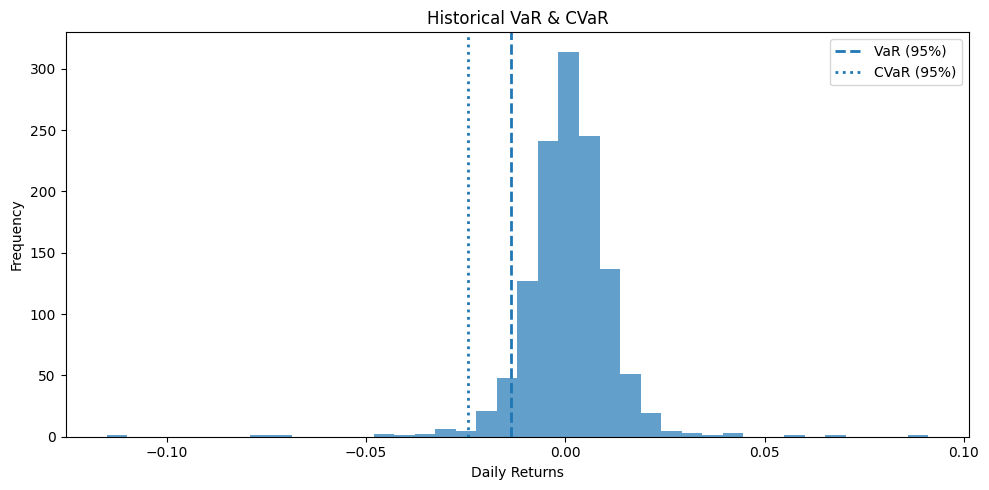



FILES SAVED SUCCESSFULLY
1. CVaR_Portfolio_Weights.csv
2. CVaR_Performance_Comparison.csv
3. CVaR_Portfolio_Allocation.png
4. CVaR_vs_Markowitz_vs_NIFTY.png
5. Tail_Risk_Distribution.png

Project Completed Successfully!


In [4]:
# ============================================================
# CUMULATIVE RETURNS
# ============================================================

cvar_cumulative = (1 + cvar_returns).cumprod()

mv_cumulative = (1 + mv_returns).cumprod()

benchmark_cumulative = (1 + benchmark_series).cumprod()

# ============================================================
# CVAR PORTFOLIO WEIGHTS
# ============================================================

weights_df = pd.DataFrame({

    "Asset": assets,

    "Weight": np.round(
        optimal_weights,
        4
    )

})

# ============================================================
# PORTFOLIO ALLOCATION
# ============================================================

plt.figure(figsize=(10,5))

plt.bar(

    weights_df["Asset"],

    weights_df["Weight"]

)

plt.title("CVaR Optimized Portfolio Allocation")

plt.xlabel("Assets")

plt.ylabel("Portfolio Weight")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "CVaR_Portfolio_Allocation.png"
)

plt.show()

# ============================================================
# CUMULATIVE RETURN COMPARISON
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(

    cvar_cumulative,

    linewidth=2,

    label="CVaR Portfolio"

)

plt.plot(

    mv_cumulative,

    linewidth=2,

    label="Mean-Variance Portfolio"

)

plt.plot(

    benchmark_cumulative,

    linewidth=2,

    label="NIFTY 50"

)

plt.title("CVaR Portfolio vs Mean-Variance vs NIFTY 50")

plt.xlabel("Date")

plt.ylabel("Growth of ₹1")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    "CVaR_vs_Markowitz_vs_NIFTY.png"
)

plt.show()

# ============================================================
# TAIL RISK DISTRIBUTION
# ============================================================

portfolio_var = np.percentile(
    cvar_returns,
    5
)

portfolio_cvar = cvar_returns[
    cvar_returns <= portfolio_var
].mean()

plt.figure(figsize=(10,5))

plt.hist(

    cvar_returns,

    bins=40,

    alpha=0.7

)

plt.axvline(

    portfolio_var,

    linewidth=2,

    linestyle="--",

    label="VaR (95%)"

)

plt.axvline(

    portfolio_cvar,

    linewidth=2,

    linestyle=":",

    label="CVaR (95%)"

)

plt.title("Historical VaR & CVaR")

plt.xlabel("Daily Returns")

plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    "Tail_Risk_Distribution.png"
)

plt.show()

# ============================================================
# EXPORT RESULTS
# ============================================================

weights_df.to_csv(

    "CVaR_Portfolio_Weights.csv",

    index=False

)

comparison.to_csv(

    "CVaR_Performance_Comparison.csv",

    index=False

)

# ============================================================
# FILES SAVED
# ============================================================

print("\n")

print("="*80)

print("FILES SAVED SUCCESSFULLY")

print("="*80)

print("1. CVaR_Portfolio_Weights.csv")
print("2. CVaR_Performance_Comparison.csv")
print("3. CVaR_Portfolio_Allocation.png")
print("4. CVaR_vs_Markowitz_vs_NIFTY.png")
print("5. Tail_Risk_Distribution.png")

print("\nProject Completed Successfully!")